<a href="https://colab.research.google.com/github/MelB18/EasyQuanten/blob/main/Dekohaerenz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Klassische Wahrscheinlichkeitsverteilung

In [ ]:
import numpy as np

# 1. Wahrscheinklichteisdichteverteilungen definieren (Beispiel: 75% für 0 und 25% für 1)
p_0 = 0.75
p_1 = 1.0 - p_0

# 2. Simulation von 1000 Messungen (Zufallsauswahl basierend auf den Wahrscheinlichkeiten)
anzahl_messungen = 1000
ergebnisse = np.random.choice([0, 1], size=anzahl_messungen, p=[p_0, p_1])

# 3. Auswertung
counts_0 = np.sum(ergebnisse == 0)
counts_1 = np.sum(ergebnisse == 1)

print(f"Ergebnis nach {anzahl_messungen} Messungen")
print(f"0: {counts_0} mal gemessen ({counts_0/anzahl_messungen*100:.1f}%)")
print(f"1: {counts_1} mal gemessen ({counts_1/anzahl_messungen*100:.1f}%)")


Ergebnis nach 1000 Messungen
0: 735 mal gemessen (73.5%)
1: 265 mal gemessen (26.5%)


2 verschränkte Qubits

In [2]:
%pip install qiskit
%pip install qiskit_aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 92.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 80.6 MB/s eta 0:00:00


In [3]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# 1. Quantenschaltkreis mit 2 Qubits und 2 klassischen Bits erstellen
qc = QuantumCircuit(2, 2)

# 2. Verschränkung erzeugen (Bell-Zustand |Φ+>)
qc.h(0)          # Setzt das erste Qubit in Superposition (|0> + |1>)
qc.cx(0, 1)      # CNOT-Gatter verschränkt Qubit 0 (Control) mit Qubit 1 (Target)

# 3. Messung beider Qubits
qc.measure([0, 1], [0, 1])

# 4. Simulation auf einem idealen Quantencomputer-Simulator
simulator = AerSimulator()
result = simulator.run(qc, shots=1000).result()
counts = result.get_counts(qc)

# 5. Ergebnis ausgeben
print("Messergebnisse nach 1000 Durchläufen:")
print(f"Zustand |00>: {counts.get('00', 0)} mal")
print(f"Zustand |11>: {counts.get('11', 0)} mal")
print(f"Fehlkombinationen (|01> oder |10>): {counts.get('01', 0) + counts.get('10', 0)} mal")


Messergebnisse nach 1000 Durchläufen:
Zustand |00>: 493 mal
Zustand |11>: 507 mal
Fehlkombinationen (|01> oder |10>): 0 mal


Wenn beide Qubits in der Z-Basis gemessen werden, sind die Ergebnisse perfekt korreliert (00 oder 11).

Wenn beide Qubits in der X-Basis gemessen werden, sind die Ergebnisse ebenfalls perfekt korreliert (++ oder --).

Wenn wir jedoch Mischmessungen durchführen (Qubit 1 in Z-Basis, Qubit 2 in X-Basis), bricht die Korrelation komplett zusammen! Jede der vier Kombinationen (0+, 0-, 1+, 1-) tritt dann mit einer Wahrscheinlichkeit von 25 % auf.

In [5]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

def simuliere_basis(messung_q0_in_x, messung_q1_in_x):
    qc = QuantumCircuit(2, 2)

    # 1. Verschränkung erzeugen (|Φ+>)
    qc.h(0)
    qc.cx(0, 1)

    # 2. Basisänderung vor der Messung (Zustandsrotation)
    if messung_q0_in_x:
      qc.h(0) # Rotiert Qubit 0 von X-Basis nach Z-Basis
    if messung_q1_in_x:
      qc.h(1) # Rotiert Qubit 1 von X-Basis nach Z-Basis

    # 3. Messung
    qc.measure([0, 1], [0, 1])

    # Simulation ausführen
    simulator = AerSimulator()
    return simulator.run(qc, shots=1000).result().get_counts()

# Szenario A: Beide Qubits in der X-Basis messen
print("Szenario A (Beide X-Basis):", simuliere_basis(messung_q0_in_x=True, messung_q1_in_x=True))
# Ergebnis zeigt perfekte Korrelation (Bitstrings '00' steht für '++', '11' für '--')

print("Szenario B (Beide Z-Basis):", simuliere_basis(messung_q0_in_x=False, messung_q1_in_x=False))

# Szenario B: Gekreuzte Messung (Q0 in Z-Basis, Q1 in X-Basis)
print("Szenario C (Gekreuzte Basis):", simuliere_basis(messung_q0_in_x=False, messung_q1_in_x=True))
# Ergebnis zeigt Gleichverteilung (Verschränkungseffekt für diese Kombination unsichtbar)


Szenario A (Beide X-Basis): {'00': 507, '11': 493}
Szenario B (Beide Z-Basis): {'00': 495, '11': 505}
Szenario C (Gekreuzte Basis): {'01': 252, '11': 246, '10': 249, '00': 253}


# Simulation eines partiellen Kollapses

Die Matrix für eine schwache Messung wird nicht über eine klassische, unumkehrbare Projektionsmatrix definiert, sondern über sogenannte Kraus-Operatoren (auch Messoperatoren genannt). Diese Operatoren beschreiben mathematisch, wie das System durch die unvollständige Informationsentnahme beeinflusst wird. Da ein Quantenbit (Qubit) zwei mögliche Messergebnisse liefern kann (Ergebnis 0 oder Ergebnis 1), gibt es für eine schwache Messung in der Standard-Z-Basis zwei verschiedene Matrizen, M0 und M1.

In [6]:
import numpy as np

# 1. Startzustand festlegen (z.B. ungleiche Superposition: 60% für |0>, 40% für |1>)
p_0_start = 0.60
alpha = np.sqrt(p_0_start)
beta = np.sqrt(1.0 - p_0_start)
print(f"1. Startzustand:          P(|0>) = {alpha**2*100:.1f}%, P(|1>) = {beta**2*100:.1f}%")

# Messstärke der schwachen Messung (p = 0.40)
p = 0.40

# --- SCHRITT 1: Erste schwache Messung ---
# Wir nehmen an, der Detektor misst das Ergebnis '0' (erfolgreicher Pfad für das Protokoll)
alpha_1 = alpha
beta_1 = beta * np.sqrt(1 - p)

# Normieren
norm_1 = np.sqrt(alpha_1**2 + beta_1**2)
alpha_1 /= norm_1
beta_1 /= norm_1
print(f"2. Nach schwacher Messung: P(|0>) = {alpha_1**2*100:.1f}%, P(|1>) = {beta_1**2*100:.1f}% (Zustand verzerrt)")

# --- SCHRITT 2: Das X-Gatter (Bit-Flip) ---
# Vertauscht alpha und beta
alpha_2 = beta_1
beta_2 = alpha_1
print(f"3. Nach X-Gatter:          P(|0>) = {alpha_2**2*100:.1f}%, P(|1>) = {beta_2**2*100:.1f}% (Spiegelung)")

# --- SCHRITT 3: Zweite schwache Messung ---
# Der Detektor muss für eine erfolgreiche Umkehrung wieder '0' messen
alpha_3 = alpha_2
beta_3 = beta_2 * np.sqrt(1 - p)

# Normieren
norm_3 = np.sqrt(alpha_3**2 + beta_3**2)
alpha_3 /= norm_3
beta_3 /= norm_3

# --- SCHRITT 4: Finaler Bit-Flip zum Zurückdrehen ---
alpha_final = beta_3
beta_final = alpha_3

print(f"4. Nach Uncollapse-Reset:  P(|0>) = {alpha_final**2*100:.1f}%, P(|1>) = {beta_final**2*100:.1f}% (Exakter Ausgangszustand!)")


1. Startzustand:          P(|0>) = 60.0%, P(|1>) = 40.0%
2. Nach schwacher Messung: P(|0>) = 71.4%, P(|1>) = 28.6% (Zustand verzerrt)
3. Nach X-Gatter:          P(|0>) = 28.6%, P(|1>) = 71.4% (Spiegelung)
4. Nach Uncollapse-Reset:  P(|0>) = 60.0%, P(|1>) = 40.0% (Exakter Ausgangszustand!)


In [17]:
import numpy as np

# Startzustand: Perfekte Superposition
psi = 1.0 / np.sqrt(2) * np.array([[1], [1]])
print("Startzustand:")
print(psi)

rho_start = psi @ psi.T # Dichtematrix zu Beginn

print("Ausgangs-Dichtematrix (p=0):")

print(rho_start)
print("-> Die Nebendiagonalen (Kohärenzen) sind 0.5. Das System ist rein.")
print("-" * 50)

# Funktion zur Berechnung des gemischten Zustands nach einer Messung mit Stärke p
def berechne_quanten_mischung(p):
    # Kraus-Operatoren definieren
    M0 = np.array([[1, 0], [0, np.sqrt(1 - p)]])
    M1 = np.array([[np.sqrt(1 - p), 0], [0, 1]])

    # Zustand nach Mittelung über beide Messergebnisse (M0 und M1)
    rho_end = (M0 @ rho_start @ M0.T) + (M1 @ rho_start @ M1.T)

    # Normalisierung: Die Spur einer Dichtematrix muss 1 sein
    trace = np.trace(rho_end)
    rho_end /= trace

    return rho_end

# Test bei schwacher Messtärke (p = 0.2)
print("Dichtematrix bei p=0.2 (Schwache Messung):")
rho_schwache = berechne_quanten_mischung(0.2)
print(rho_schwache)
print("-"*50)

# Test bei mittlerer Messstärke (p = 0.5)
rho_mittel = berechne_quanten_mischung(0.5)
print("Dichtematrix bei p=0.5 (Mittelstarker Messung):")
print(rho_mittel)
print("-" * 50)

# Test bei starker Messung (p = 1.0)
rho_stark = berechne_quanten_mischung(1.0)
print("Dichtematrix bei p=1.0 (Starke Messung / Vollständiger Kollaps):")
print(rho_stark)
print("-> Die Nebendiagonalen sind exakt 0. Jede Quantenüberlagerung ist zerstört.")


Startzustand:
[[0.70710678]
 [0.70710678]]
Ausgangs-Dichtematrix (p=0):
[[0.5 0.5]
 [0.5 0.5]]
-> Die Nebendiagonalen (Kohärenzen) sind 0.5. Das System ist rein.
--------------------------------------------------
Dichtematrix bei p=0.2 (Schwache Messung):
[[0.5        0.49690399]
 [0.49690399 0.5       ]]
--------------------------------------------------
Dichtematrix bei p=0.5 (Mittelstarker Messung):
[[0.5        0.47140452]
 [0.47140452 0.5       ]]
--------------------------------------------------
Dichtematrix bei p=1.0 (Starke Messung / Vollständiger Kollaps):
[[0.5 0. ]
 [0.  0.5]]
-> Die Nebendiagonalen sind exakt 0. Jede Quantenüberlagerung ist zerstört.


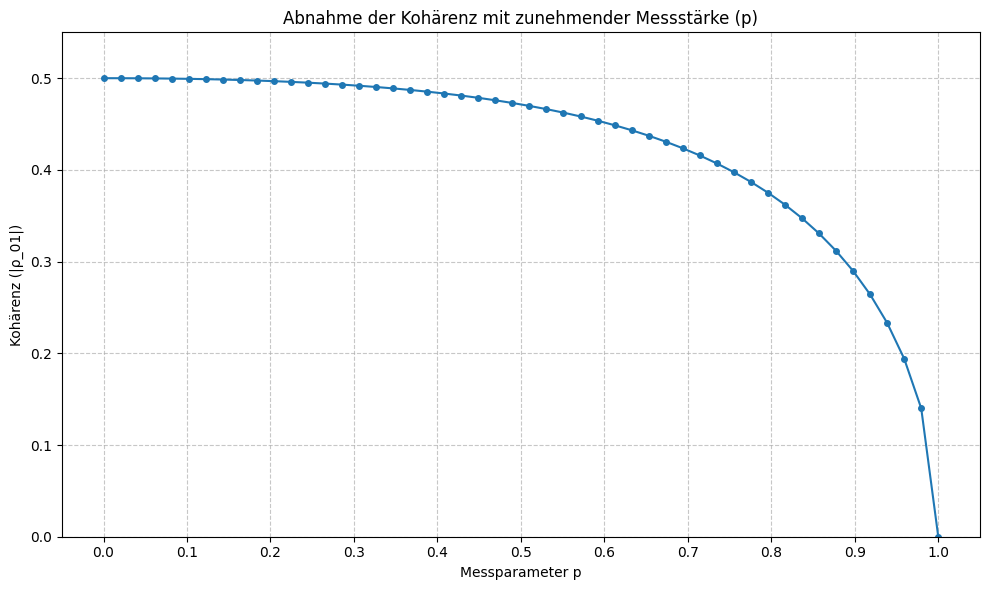

In [18]:
import matplotlib.pyplot as plt

# Definiere einen Bereich für den Messparameter p
p_werte = np.linspace(0, 1, 50) # 50 Werte von 0 bis 1

# Liste zum Speichern der Kohärenzwerte
kohaerenz_werte = []

# Berechne die Kohärenz für jeden p-Wert
for p_val in p_werte:
    rho = berechne_quanten_mischung(p_val)
    # Die Kohärenz wird durch die Nicht-Diagonalelemente repräsentiert
    # np.abs ist wichtig, da es sich um komplexe Zahlen handeln kann, auch wenn hier reell
    kohaerenz_werte.append(np.abs(rho[0, 1]))

# Plot der Kohärenz als Funktion von p
plt.figure(figsize=(10, 6))
plt.plot(p_werte, kohaerenz_werte, marker='o', linestyle='-', markersize=4)
plt.title('Abnahme der Kohärenz mit zunehmender Messstärke (p)')
plt.xlabel('Messparameter p')
plt.ylabel('Kohärenz (|ρ_01|)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0, 0.55) # Setze Y-Achse, da max. Kohärenz 0.5 ist
plt.xticks(np.arange(0, 1.1, 0.1)) # Mehr Ticks auf der X-Achse
plt.tight_layout()
plt.show()

In [38]:
import numpy as np

# 1. Pauli-Matrizen definieren
sigma_x = np.array([[0, 1], [1, 0]])
sigma_y = np.array([[0, -1j], [1j, 0]])
sigma_z = np.array([[1, 0], [0, -1]])

# Start-Dichtematrix für die perfekte Superposition: (|0> + |1>)/sqrt(2)
# psi_complex = 1.0 / np.sqrt(2) * np.array([[1], [1]])
psi_complex = np.array([[-4/5], [3/5]])
rho_start = psi_complex @ psi_complex.T.conj()

def extrahiere_bloch_koordinaten(rho):
    # Berechnung über die Spur (Trace)
    x = np.real(np.trace(rho @ sigma_x))
    y = np.real(np.trace(rho @ sigma_y))
    z = np.real(np.trace(rho @ sigma_z))
    # Radius (Abstand zum Mittelpunkt)
    r = np.sqrt(x**2 + y**2 + z**2)
    return x, y, z, r

def simuliere_messstaerke(p):
    # Kraus-Operatoren für die Z-Basis-Messung
    M0 = np.array([[1, 0], [0, np.sqrt(1 - p)]])
    M1 = np.array([[np.sqrt(1 - p), 0], [0, 1]])

    # Statistischer Zustand (Ensemble-Mittel ohne Bekanntgabe des Ergebnisses)
    rho_gemischt = (M0 @ rho_start @ M0.T) + (M1 @ rho_start @ M1.T)

    # Normalisierung der Dichtematrix, damit r <= 1 ist
    trace = np.trace(rho_gemischt)
    rho_gemischt /= trace

    return extrahiere_bloch_koordinaten(rho_gemischt)

# Test für verschiedene Phasen des Übergangs
for p in [0.0, 0.3, 0.7, 1.0]:
    x, y, z, r = simuliere_messstaerke(p)
    status = "Oberfläche (Rein)" if np.isclose(r, 1.0) else f"Kugelinneres (Gemischt, r={r:.3f})"
    print(f"Messstärke p = {p:.1f} -> Koordinaten: (X={x:.3f}, Y={y:.3f}, Z={z:.3f}) | Zustand ist im {status}")

Messstärke p = 0.0 -> Koordinaten: (X=-0.960, Y=0.000, Z=0.280) | Zustand ist im Oberfläche (Rein)
Messstärke p = 0.3 -> Koordinaten: (X=-0.945, Y=0.000, Z=0.280) | Zustand ist im Kugelinneres (Gemischt, r=0.986)
Messstärke p = 0.7 -> Koordinaten: (X=-0.809, Y=0.000, Z=0.280) | Zustand ist im Kugelinneres (Gemischt, r=0.856)
Messstärke p = 1.0 -> Koordinaten: (X=0.000, Y=0.000, Z=0.280) | Zustand ist im Kugelinneres (Gemischt, r=0.280)


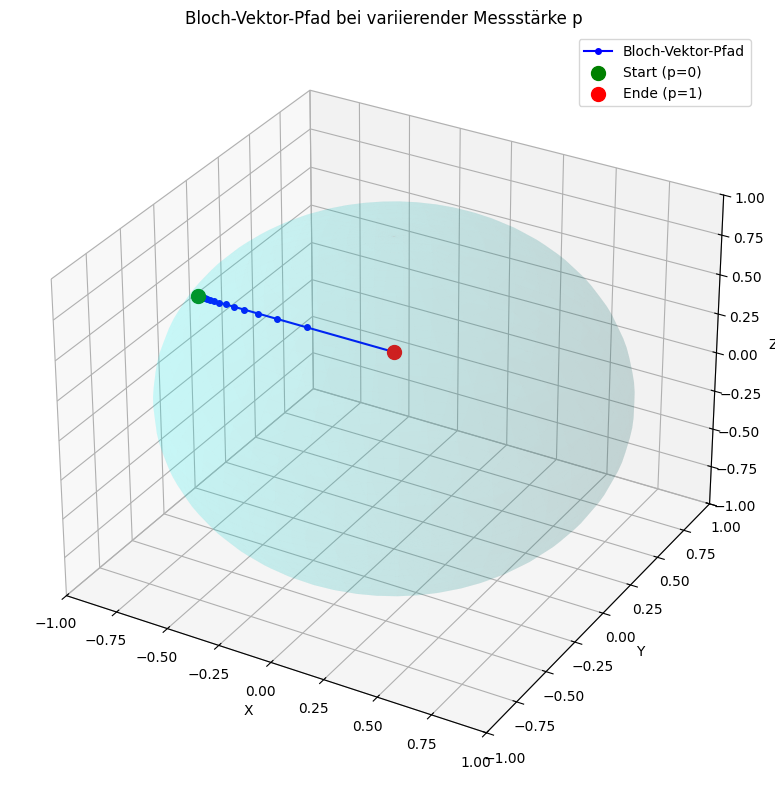

In [41]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Definiere einen feineren Bereich für den Messparameter p, um einen glatteren Pfad zu erhalten
p_werte = np.linspace(0, 1, 20) # 100 Werte von 0 bis 1

# Listen zum Speichern der Bloch-Koordinaten
bloch_x = []
bloch_y = []
bloch_z = []

# Berechne die Bloch-Koordinaten für jeden p-Wert
for p_val in p_werte:
    x, y, z, _ = simuliere_messstaerke(p_val)
    bloch_x.append(x)
    bloch_y.append(y)
    bloch_z.append(z)

# Erstelle die 3D-Bloch-Kugel für den Hintergrund
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

u = np.linspace(0, 2 * np.pi, 50)
v = np.linspace(0, np.pi, 50)
x_sphere = np.outer(np.cos(u), np.sin(v))
y_sphere = np.outer(np.sin(u), np.sin(v))
z_sphere = np.outer(np.ones(np.size(u)), np.cos(v))

# Zeichne die Bloch-Kugel (transparent)
ax.plot_surface(x_sphere, y_sphere, z_sphere, color='cyan', alpha=0.1)

# Zeichne den Pfad des Bloch-Vektors
ax.plot(bloch_x, bloch_y, bloch_z, color='blue', marker='o', markersize=4, linestyle='-', label='Bloch-Vektor-Pfad')

# Beschriftungen und Titel
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Bloch-Vektor-Pfad bei variierender Messstärke p')
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])

# Initial- und Endpunkt hervorheben
ax.scatter(bloch_x[0], bloch_y[0], bloch_z[0], color='green', s=100, label='Start (p=0)', depthshade=True)
ax.scatter(bloch_x[-1], bloch_y[-1], bloch_z[-1], color='red', s=100, label='Ende (p=1)', depthshade=True)

ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()